In [56]:
%matplotlib inline
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('datasetEDA.csv', sep=';')
df.head()


,Timestamp,Location_Lat,Location_Long,Crowd_Density,Movement_Speed,Activity_Type,Weather_Conditions,Temperature,Sound_Level_dB,AR_System_Interaction,...,Incident_Type,Crowd_Morale,Pilgrim_Experience,Interaction_Frequency,Distance_Between_People_m,Event_Type,Time_Spent_at_Location_minutes,AR_Navigation_Success,Satisfaction_Rating,Perceived_Safety_Rating
0,28/02/24 05:36,21.258846,39.983949,High,0.90,Tawaf,Clear,44,82,Started,...,Theft,Neutral,Experienced,6,0.94,Transport Delay,77,No,2,3
1,15/07/24 04:07,21.353403,39.850382,Low,0.55,Resting,Clear,39,80,Completed,...,Security Breach,Negative,First-Time,8,2.04,Religious Activity,92,No,2,3
2,06/06/24 08:27,21.252375,39.937753,Medium,0.94,Prayer,Clear,32,84,Started,...,Unruly Behavior,Negative,Experienced,2,1.85,Crowd Congestion,16,Yes,5,4
3,23/12/24 06:29,21.377740,39.813333,Medium,0.55,Prayer,Clear,41,79,Started,...,Unruly Behavior,Negative,Experienced,2,0.96,Transport Delay,74,No,3,3
4,19/08/24 18:00,21.360457,39.950974,High,0.36,Sa’i,Rainy,44,67,Completed,...,Theft,Negative,First-Time,10,1.05,Transport Delay,20,No,3,1


In [ ]:
df.shape


(10000, 30)

In [13]:
df.drop(columns=['Location_Lat','Location_Long'], inplace=True)


In [14]:
df.drop(columns=['Nationality'], inplace=True)

In [7]:
df.columns

Index(['Timestamp', 'Location_Lat', 'Location_Long', 'Crowd_Density',
       'Movement_Speed', 'Activity_Type', 'Weather_Conditions', 'Temperature',
       'Sound_Level_dB', 'AR_System_Interaction', 'Fatigue_Level',
       'Stress_Level', 'Queue_Time_minutes', 'Health_Condition', 'Age_Group',
       'Nationality', 'Transport_Mode', 'Waiting_Time_for_Transport',
       'Security_Checkpoint_Wait_Time', 'Emergency_Event', 'Incident_Type',
       'Crowd_Morale', 'Pilgrim_Experience', 'Interaction_Frequency',
       'Distance_Between_People_m', 'Event_Type',
       'Time_Spent_at_Location_minutes', 'AR_Navigation_Success',
       'Satisfaction_Rating', 'Perceived_Safety_Rating'],
      dtype='str')

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 30 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Timestamp                       10000 non-null  str    
 1   Location_Lat                    10000 non-null  float64
 2   Location_Long                   10000 non-null  float64
 3   Crowd_Density                   10000 non-null  str    
 4   Movement_Speed                  10000 non-null  float64
 5   Activity_Type                   10000 non-null  str    
 6   Weather_Conditions              10000 non-null  str    
 7   Temperature                     10000 non-null  int64  
 8   Sound_Level_dB                  10000 non-null  int64  
 9   AR_System_Interaction           10000 non-null  str    
 10  Fatigue_Level                   10000 non-null  str    
 11  Stress_Level                    10000 non-null  str    
 12  Queue_Time_minutes              10000 non-nu

In [20]:
df.isnull().sum()

Timestamp                         0
Location_Lat                      0
Location_Long                     0
Crowd_Density                     0
Movement_Speed                    0
Activity_Type                     0
Weather_Conditions                0
Temperature                       0
Sound_Level_dB                    0
AR_System_Interaction             0
Fatigue_Level                     0
Stress_Level                      0
Queue_Time_minutes                0
Health_Condition                  0
Age_Group                         0
Nationality                       0
Transport_Mode                    0
Waiting_Time_for_Transport        0
Security_Checkpoint_Wait_Time     0
Emergency_Event                   0
Incident_Type                     0
Crowd_Morale                      0
Pilgrim_Experience                0
Interaction_Frequency             0
Distance_Between_People_m         0
Event_Type                        0
Time_Spent_at_Location_minutes    0
AR_Navigation_Success       

In [21]:
df.describe()

,Location_Lat,Location_Long,Movement_Speed,Temperature,Sound_Level_dB,Queue_Time_minutes,Waiting_Time_for_Transport,Security_Checkpoint_Wait_Time,Interaction_Frequency,Distance_Between_People_m,Time_Spent_at_Location_minutes,Satisfaction_Rating,Perceived_Safety_Rating
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,21.299628,39.898729,0.845493,37.515400,74.914200,30.256500,59.661500,17.578400,4.969700,1.497744,65.018600,3.010100,2.986800
std,0.057664,0.057236,0.377836,4.610736,9.007439,17.681492,35.093146,7.529829,3.167015,0.570497,32.039608,1.425623,1.416554
min,21.200078,39.800043,0.200000,30.000000,60.000000,0.000000,0.000000,5.000000,0.000000,0.500000,10.000000,1.000000,1.000000
25%,21.249454,39.849039,0.520000,33.000000,67.000000,15.000000,29.000000,11.000000,2.000000,1.010000,37.000000,2.000000,2.000000
50%,21.299998,39.899346,0.840000,38.000000,75.000000,30.000000,59.000000,18.000000,5.000000,1.490000,65.000000,3.000000,3.000000
75%,21.349764,39.947166,1.170000,42.000000,83.000000,46.000000,90.000000,24.000000,8.000000,1.990000,93.000000,4.000000,4.000000
max,21.399917,39.999994,1.500000,45.000000,90.000000,60.000000,120.000000,30.000000,10.000000,2.500000,120.000000,5.000000,5.000000


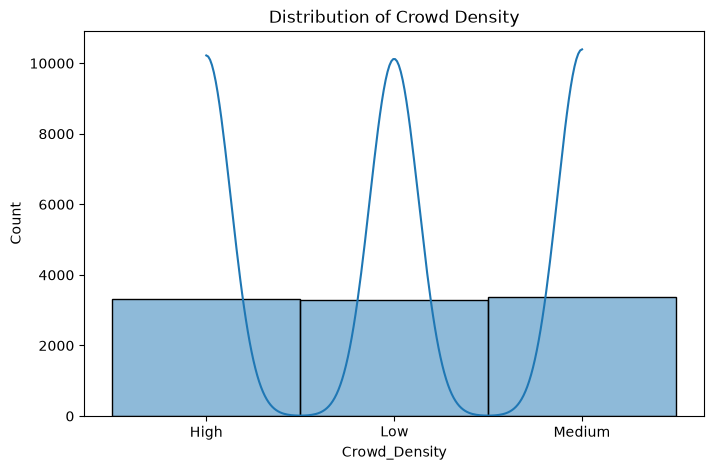

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df['Crowd_Density'], bins=30, kde=True)
plt.title('Distribution of Crowd Density')
plt.show()

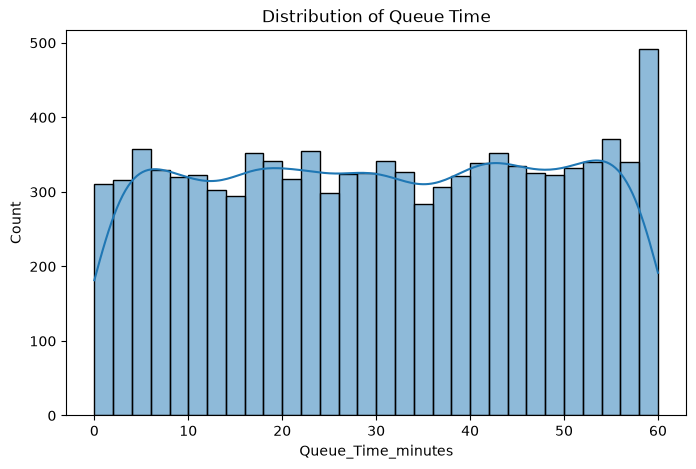

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df['Queue_Time_minutes'], bins=30, kde=True)
plt.title('Distribution of Queue Time')
plt.show()

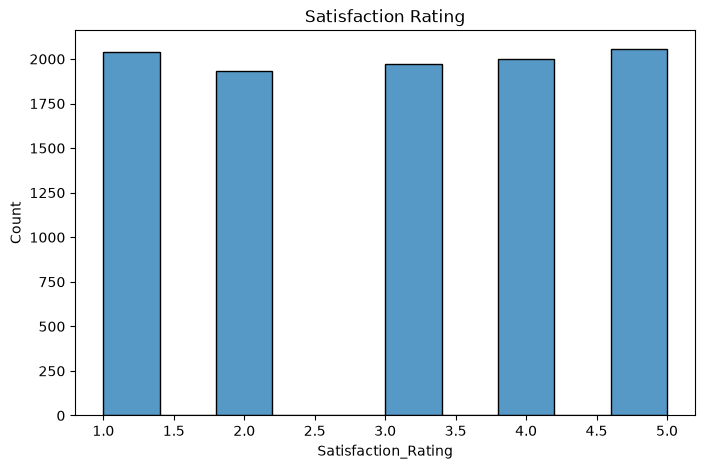

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(df['Satisfaction_Rating'], bins=10)
plt.title('Satisfaction Rating')
plt.show()

In [72]:
import numpy as np

df['Adjusted_Temperature'] = np.where(
    df['Weather_Conditions'] == 'Rainy',
    df['Temperature'] - 5,
    np.where(
        df['Weather_Conditions'] == 'Cloudy',
        df['Temperature'] - 2,
        df['Temperature']
    )
)

C:\Users\vhd_1\AppData\Local\Temp\ipykernel_17892\2225093406.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


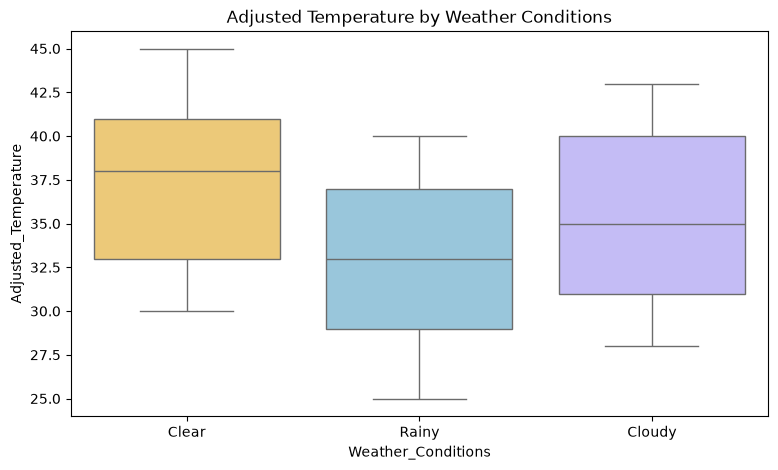

In [73]:
plt.figure(figsize=(9,5))

sns.boxplot(
    data=df,
    x='Weather_Conditions',
    y='Adjusted_Temperature',
    palette=['#FFD166','#8ECAE6','#BDB2FF']
)

plt.title('Adjusted Temperature by Weather Conditions')
plt.show()

In [74]:
import numpy as np

df['Adjusted_Waiting_Time'] = np.where(
    df['Transport_Mode'] == 'Bus',
    df['Waiting_Time_for_Transport'] + 20,
    np.where(
        df['Transport_Mode'] == 'Train',
        df['Waiting_Time_for_Transport'] + 10,
        np.where(
            df['Transport_Mode'] == 'Metro',
            df['Waiting_Time_for_Transport'] - 10,
            df['Waiting_Time_for_Transport']
        )
    )
)

C:\Users\vhd_1\AppData\Local\Temp\ipykernel_17892\2196160314.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


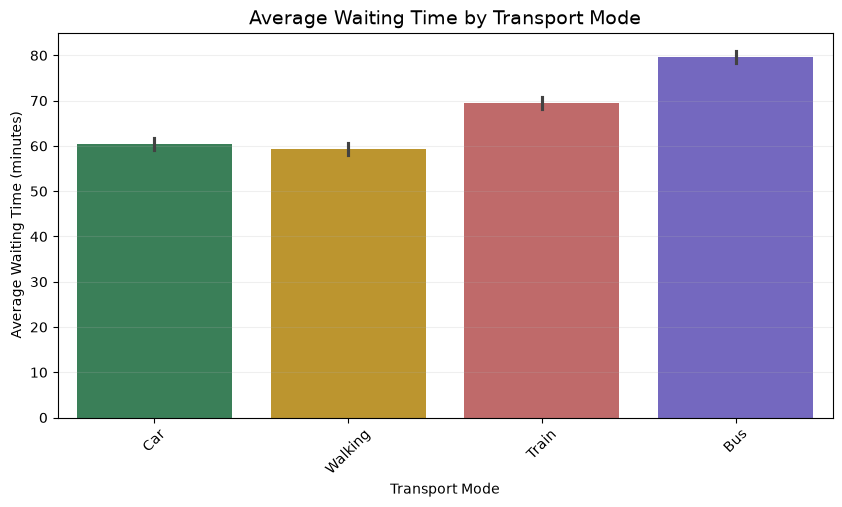

In [83]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=df,
    x='Transport_Mode',
    y='Adjusted_Waiting_Time',
    palette=['#2E8B57', '#D4A017', '#CD5C5C', '#6A5ACD']
)

plt.xticks(rotation=45)
plt.title('Average Waiting Time by Transport Mode', fontsize=14)
plt.ylabel('Average Waiting Time (minutes)')
plt.xlabel('Transport Mode')
plt.grid(axis='y', alpha=0.2)

plt.show()

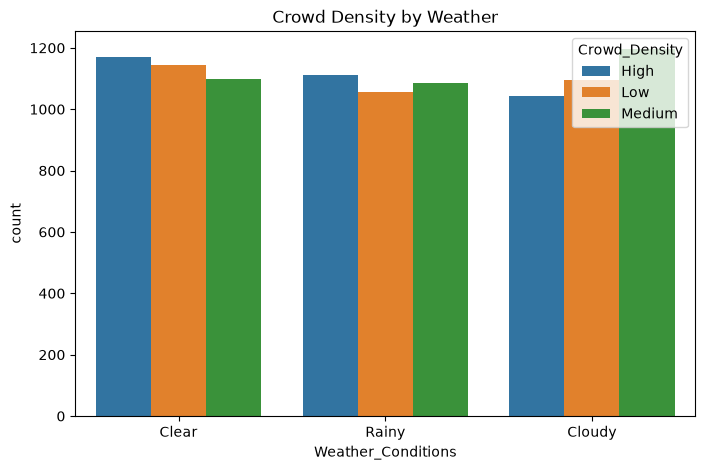

In [27]:
plt.figure(figsize=(8,5))
sns.countplot(
    x='Weather_Conditions',
    hue='Crowd_Density',
    data=df
)
plt.title('Crowd Density by Weather')
plt.show()

In [28]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'], format='%d/%m/%y %H:%M')
df['Hour'] = df['Timestamp'].dt.hour

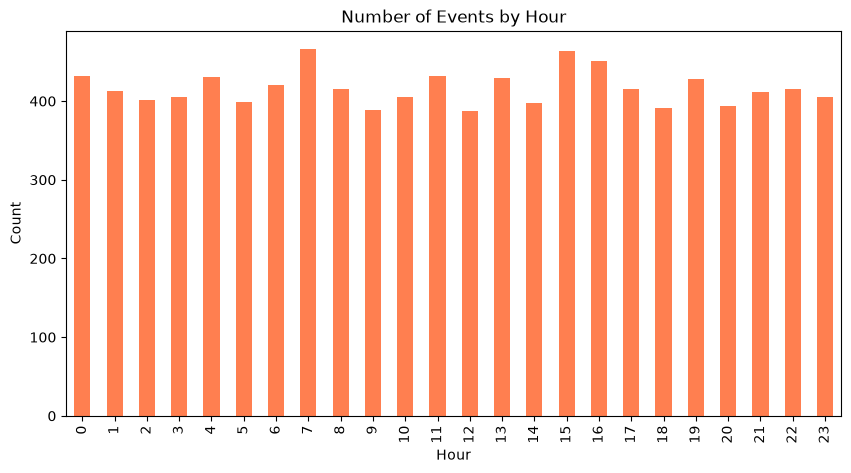

In [31]:
plt.figure(figsize=(10,5))
df['Hour'].value_counts().sort_index().plot(
    kind='bar',
    color='coral'
)
plt.title('Number of Events by Hour')
plt.xlabel('Hour')
plt.ylabel('Count')
plt.show()

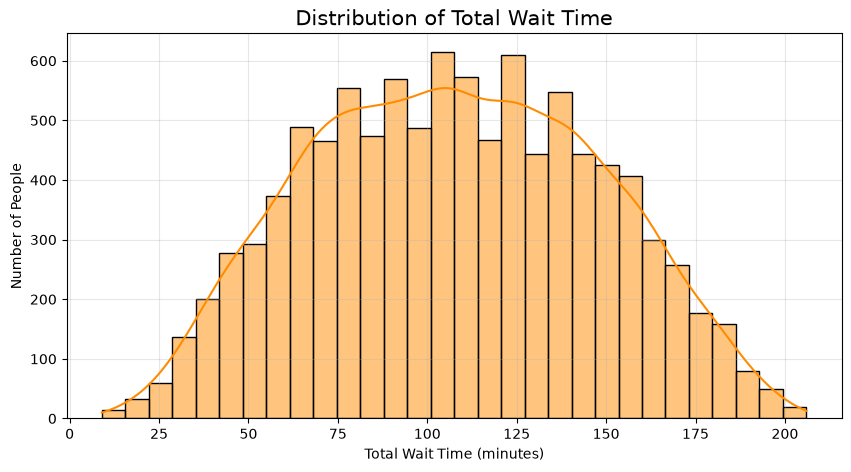

In [81]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['Total_Wait_Time'],
    bins=30,
    kde=True,
    color='darkorange'
)

plt.title('Distribution of Total Wait Time', fontsize=15)
plt.xlabel('Total Wait Time (minutes)')
plt.ylabel('Number of People')
plt.grid(alpha=0.3)
plt.show()

In [39]:
df['Crowded_Area'] = (
    df['Distance_Between_People_m'] < 1
).astype(int)

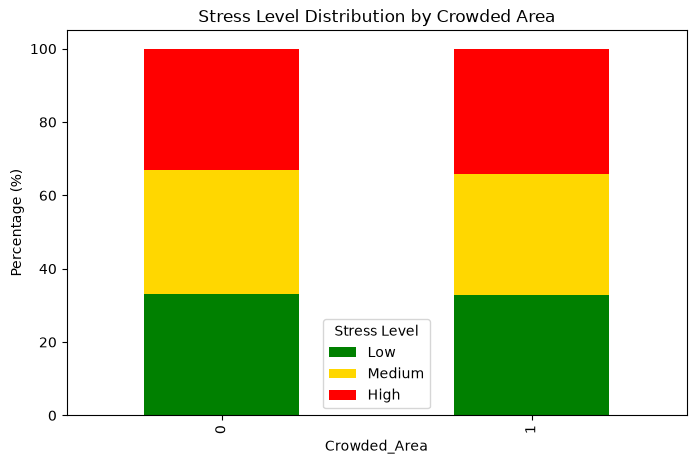

In [43]:
cross = pd.crosstab(
    df['Crowded_Area'],
    df['Stress_Level'],
    normalize='index'
) * 100

cross = cross[['Low', 'Medium', 'High']]

cross.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5),
    color=['green', 'gold', 'red']
)

plt.title('Stress Level Distribution by Crowded Area')
plt.ylabel('Percentage (%)')
plt.legend(title='Stress Level')
plt.show()